# Heart Disease Exploratory Data Analysis

**Author:** Dayton Wickerd  
**Date:** April 2025  
**Dataset:** UCI Heart Disease — Processed Cleveland Subset ([source](https://archive.ics.uci.edu/dataset/45/heart+disease))  

---

This project performs exploratory data analysis on the Heart Disease dataset from the UCI Machine Learning Repository. Using the processed Cleveland subset (303 patient records, 13 physiological features), we investigate which clinical indicators are most associated with heart disease severity. All statistical functions — including covariance, correlation, and normalization — are implemented from scratch without scikit-learn or scipy, using only NumPy and pandas.


In [148]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11

os.makedirs('figures', exist_ok=True)

# Column names from the UCI data dictionary
cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv('data/processed_cleveland.data', names=cols, na_values='?')

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
# Problem 1 — Dataset Overview

## 1a) What is the data used for?

We used the Heart Disease dataset from the UCI Machine Learning Repository. It is used to study the presence and severity of heart disease in patients. For this project, we used specifically the processed Cleveland subset, which contains 303 patient records. The data is composed of physiological indicators such as resting blood pressure, cholesterol, and maximum heart rate during exercise. It also contains demographic information like age and sex. The target variable (`target`) is an integer from 0 to 4, where 0 indicates no heart disease and 1–4 indicate increasing severity. The goal is to predict whether, and to what degree, a patient has heart disease. Other than classification, the dataset can also be used to identify which features are associated with cardiac conditions. This can potentially make it cheaper and easier to screen and diagnose conditions.

## 1b) Who uploaded the data?

The processed Cleveland dataset was created by Robert Detrano, M.D., Ph.D. at the V.A. Medical Center, Long Beach, and the Cleveland Clinic Foundation. The broader Heart Disease dataset also includes contributions from Andras Janosi (Hungarian Institute of Cardiology, Budapest), William Steinbrunn (University Hospital, Zurich), and Matthias Pfisterer (University Hospital, Basel).

## 1c) Attributes and entries

In [149]:
print(f'Total entries (rows): {df.shape[0]}')
print(f'Total attributes (columns): {df.shape[1]}')
print()
print('Attribute overview:')
print(df.dtypes)

Total entries (rows): 303
Total attributes (columns): 14

Attribute overview:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


### Attribute breakdown

Age
Type: Numerical (continuous)
Description: Age in years

Sex
Type: Categorical (binary)
Description: 1 = male, 0 = female

Cp
Type: Categorical (nominal)
Description: Chest pain type
1 = typical angina
2 = atypical angina
3 = non-anginal pain
4 = asymptomatic

Trestbps
Type: Numerical (continuous)
Description: Resting blood pressure in mm Hg on admission

Chol
Type: Numerical (continuous)
Description: Serum cholesterol in mg per deciliter

Fbs
Type: Categorical (binary)
Description: Fasting blood sugar greater than 120 mg per deciliter
1 = true
0 = false

Restecg
Type: Categorical (nominal)
Description: Resting ECG results
0 = normal
1 = ST-T wave abnormality
2 = left ventricular hypertrophy

Thalach
Type: Numerical (continuous)
Description: Maximum heart rate achieved

Exang
Type: Categorical (binary)
Description: Exercise-induced angina
1 = yes
0 = no

Oldpeak
Type: Numerical (continuous)
Description: ST depression induced by exercise relative to rest

Slope
Type: Categorical (ordinal)
Description: Slope of peak exercise ST segment
1 = upsloping
2 = flat
3 = downsloping

Ca
Type: Numerical (discrete)
Description: Number of major vessels colored by fluoroscopy (0 to 3)

Thal
Type: Categorical (nominal)
Description: Thalassemia
3 = normal
6 = fixed defect
7 = reversible defect

Target
Type: Categorical (ordinal)
Description: Diagnosis of heart disease
0 = no disease
1 to 4 = increasing severity

In [150]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

print(f'Number of numerical attributes: {len(numerical_cols)}')
print(f'Number of categorical attributes: {len(categorical_cols)}')

Number of numerical attributes: 6
Number of categorical attributes: 8


### 1c-iii) Encoding recommendation for each categorical attribute

Sex
Recommendation: Label (Integer) Encoding
Reason: This is a binary attribute (0 and 1). There are only two classes, so label encoding is sufficient and effectively equivalent to one-hot encoding.

Cp
Recommendation: One-Hot Encoding
Reason: This attribute has four nominal categories (typical angina, atypical angina, non-anginal pain, asymptomatic). There is no meaningful numeric ordering between pain types, so integer encoding would incorrectly imply a ranking.

Fbs
Recommendation: Label (Integer) Encoding
Reason: This is a binary attribute (0 and 1). It is already numerically meaningful, indicating whether fasting blood sugar is above the threshold or not.

Restecg
Recommendation: One-Hot Encoding
Reason: This attribute has three categories (normal, ST-T wave abnormality, left ventricular hypertrophy) with no clear ordinal relationship. Integer encoding would imply a false order.

Exang
Recommendation: Label (Integer) Encoding
Reason: This is a binary attribute (0 and 1). It is already encoded as a boolean variable.

Slope
Recommendation: Label (Integer) Encoding
Reason: This attribute has three ordered categories (1 = upsloping, 2 = flat, 3 = downsloping). It has a natural ordinal interpretation, so integer encoding preserves the meaningful ordering.

Thal
Recommendation: One-Hot Encoding
Reason: This attribute has three categories (3 = normal, 6 = fixed defect, 7 = reversible defect). These represent nominal disease states with no inherent quantitative distance between them.

Target
Recommendation: Label (Integer) Encoding
Reason: This is an ordinal outcome variable (0 to 4) representing increasing disease severity. The integer values already encode a meaningful ordering from no disease to severe disease.

## 1d) Missing Values

In [151]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Proportion (%)': missing_pct
})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Overall missing proportion: {df.isnull().sum().sum() / df.size * 100:.2f}%')

          Missing Count  Missing Proportion (%)
age                   0                0.000000
sex                   0                0.000000
cp                    0                0.000000
trestbps              0                0.000000
chol                  0                0.000000
fbs                   0                0.000000
restecg               0                0.000000
thalach               0                0.000000
exang                 0                0.000000
oldpeak               0                0.000000
slope                 0                0.000000
ca                    4                1.320132
thal                  2                0.660066
target                0                0.000000

Total missing values: 6
Overall missing proportion: 0.14%


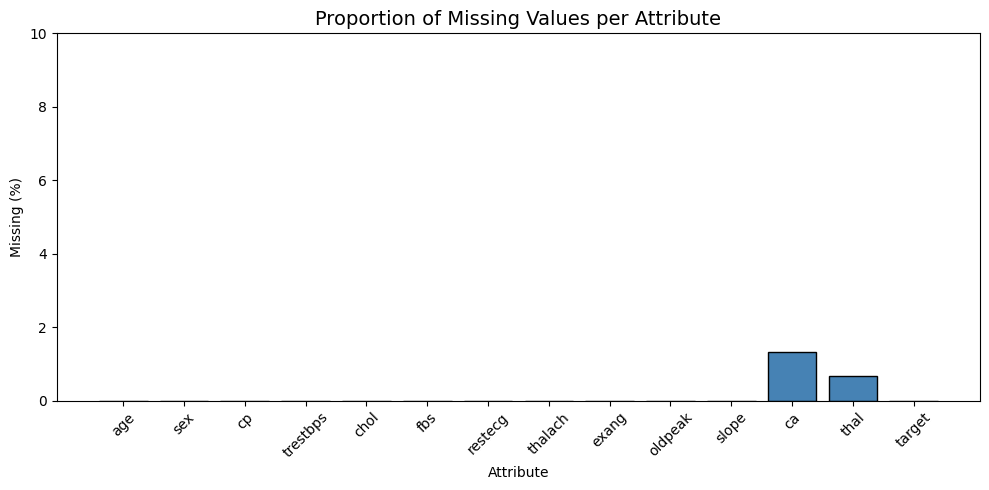

Missing values plot saved.


In [152]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(missing_df.index, missing_df['Missing Proportion (%)'], color='steelblue', edgecolor='black')
ax.set_title('Proportion of Missing Values per Attribute', fontsize=14)
ax.set_xlabel('Attribute')
ax.set_ylabel('Missing (%)')
ax.set_ylim(0, 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/missing_values.png', bbox_inches='tight')
plt.show()
print('Missing values plot saved.')

### Missing Value Analysis

The dataset contains missing values in two attributes: `ca` (number of major vessels colored by fluoroscopy) and `thal` (thalassemia type). Specifically, `ca` has 4 missing entries (1.32% of rows) and `thal` has 2 missing entries (0.66% of rows). All remaining 12 attributes are complete.

The missing values originate from `?` markers in the raw `.data` file, which pandas interprets as `NaN` when `na_values='?'` is specified at load time. Because missingness is confined to just two columns and represents only 6 out of 4,242 total cells (0.14% overall), the impact on downstream analysis is minimal.

For analyses requiring a complete numerical matrix, missing entries are handled by mean imputation — each missing value is replaced with the column mean computed from non-missing rows. This strategy retains all 303 records while introducing negligible bias given the small number of affected values.


## 1e) Most Interesting Aspect of the Dataset

Perhaps the most striking feature of this dataset is how much diagnostic signal comes from a relatively simple stress test. Attributes such as `oldpeak` (ST-segment depression), `thalach` (maximum heart rate under exercise load), and `exang` (exercise-induced angina) are all derived from a standard treadmill test, yet they appear to be among the strongest indicators of cardiac disease. This suggests that expensive imaging or invasive procedures may not always be necessary to flag high-risk patients.

A second point of interest is the structure of the target variable. Rather than a binary healthy/diseased label, severity is encoded on a 0-4 integer scale, which frames this as an ordinal classification problem rather than a simple binary one. This nuance makes the dataset more realistic and analytically richer than a yes/no label would be.


## 1f) Most Descriptive Attributes (Before Formal Analysis)

Based on physiological reasoning and clinical context, the following three attributes are expected to be the most descriptive of heart disease severity before any formal analysis is performed:

1. **`thalach` -- Maximum Heart Rate Achieved:** The peak heart rate a patient sustains under stress directly reflects cardiovascular fitness. A depressed maximum heart rate during exercise is a well-established marker of compromised cardiac function and is expected to differ substantially between healthy and diseased patients.

2. **`oldpeak` -- ST Depression Induced by Exercise:** ST-segment depression on an electrocardiogram during exercise indicates reduced coronary blood flow. Larger `oldpeak` values correspond to more pronounced ischemic changes, making this a strong candidate for a highly predictive feature.

3. **`cp` -- Chest Pain Type:** This attribute encodes medically meaningful distinctions between pain presentations -- from typical angina (directly attributable to the heart) to asymptomatic presentations. Because the four categories carry different clinical implications, `cp` is expected to be one of the most discriminative features despite being categorical.


---
# Problem 2 — Custom Python Functions


In [153]:
# Drop rows with any NaN for Problem 2 function testing
df_clean = df.dropna()
data_num = df_clean[numerical_cols].to_numpy(dtype=float)
data_cat = df_clean[categorical_cols].to_numpy()

print('Numerical data shape (NaN rows dropped):', data_num.shape)
print('Categorical data shape:', data_cat.shape)


Numerical data shape (NaN rows dropped): (297, 6)
Categorical data shape: (297, 8)


## 2a) Multi-dimensional Mean

In [154]:
def multidim_mean(data):
    n_rows, n_cols = data.shape
    means = []
    for j in range(n_cols):
        col_sum = 0.0
        for i in range(n_rows):
            col_sum += data[i, j]
        means.append(col_sum / n_rows)
    return np.array(means).reshape(1, -1)

# Test
mean_result = multidim_mean(data_num)
print('Multi-dimensional mean (shape', mean_result.shape, '):')
for name, val in zip(numerical_cols, mean_result[0]):
    print(f'  {name}: {val:.4f}')

# Verify with numpy
print('\nVerification with np.mean:')
np_mean = np.mean(data_num, axis=0)
print('  Max difference:', np.max(np.abs(mean_result[0] - np_mean)))

Multi-dimensional mean (shape (1, 6) ):
  age: 54.5421
  trestbps: 131.6936
  chol: 247.3502
  thalach: 149.5993
  oldpeak: 1.0556
  ca: 0.6768

Verification with np.mean:
  Max difference: 2.220446049250313e-16


## 2b) Sample Variance

In [155]:
def sample_variance(data, col_idx):
    n = data.shape[0]
    # Compute mean manually
    col_sum = 0.0
    for i in range(n):
        col_sum += data[i, col_idx]
    mean = col_sum / n
    
    # Compute sum of squared deviations
    sq_dev_sum = 0.0
    for i in range(n):
        diff = data[i, col_idx] - mean
        sq_dev_sum += diff * diff
    
    return sq_dev_sum / (n - 1)

# Test
print('Sample variances:')
for j, name in enumerate(numerical_cols):
    var = sample_variance(data_num, j)
    np_var = np.var(data_num[:, j], ddof=1)
    print(f'  {name}: {var:.4f}  (np check: {np_var:.4f}, diff: {abs(var - np_var):.2e})')

Sample variances:
  age: 81.8977  (np check: 81.8977, diff: 4.26e-14)
  trestbps: 315.5173  (np check: 315.5173, diff: 1.71e-13)
  chol: 2703.7486  (np check: 2703.7486, diff: 4.55e-13)
  thalach: 526.3153  (np check: 526.3153, diff: 1.14e-13)
  oldpeak: 1.3598  (np check: 1.3598, diff: 2.22e-16)
  ca: 0.8817  (np check: 0.8817, diff: 2.66e-15)


## 2c) Sample Covariance

In [156]:
def sample_covariance(data, col_i, col_j):
    n = data.shape[0]
    
    # Compute means
    sum_i, sum_j = 0.0, 0.0
    for k in range(n):
        sum_i += data[k, col_i]
        sum_j += data[k, col_j]
    mean_i = sum_i / n
    mean_j = sum_j / n
    
    # Compute sum of products of deviations
    cov_sum = 0.0
    for k in range(n):
        cov_sum += (data[k, col_i] - mean_i) * (data[k, col_j] - mean_j)
    
    return cov_sum / (n - 1)

# Test
cov_age_chol = sample_covariance(data_num, 0, 2)  # age vs chol
np_cov = np.cov(data_num[:, 0], data_num[:, 2])[0, 1]
print(f'Covariance(age, chol): {cov_age_chol:.4f}  (np check: {np_cov:.4f})')

cov_age_thalach = sample_covariance(data_num, 0, 3)  # age vs thalach
np_cov2 = np.cov(data_num[:, 0], data_num[:, 3])[0, 1]
print(f'Covariance(age, thalach): {cov_age_thalach:.4f}  (np check: {np_cov2:.4f})')

Covariance(age, chol): 95.3568  (np check: 95.3568)
Covariance(age, thalach): -81.9172  (np check: -81.9172)


## 2d) Covariance Matrix

In [157]:
def covariance_matrix(data):

    n_cols = data.shape[1]
    cov_mat = np.zeros((n_cols, n_cols))
    
    for i in range(n_cols):
        for j in range(n_cols):
            if i == j:
                cov_mat[i, j] = sample_variance(data, i)
            else:
                cov_mat[i, j] = sample_covariance(data, i, j)
    
    return cov_mat

# Test
cov_mat_num = covariance_matrix(data_num)
np_cov_mat = np.cov(data_num.T)

print('Covariance Matrix (numerical attributes):')
print(pd.DataFrame(cov_mat_num, index=numerical_cols, columns=numerical_cols).round(3))
print(f'\nMax difference from np.cov: {np.max(np.abs(cov_mat_num - np_cov_mat)):.2e}')

Covariance Matrix (numerical attributes):
             age  trestbps      chol  thalach  oldpeak     ca
age       81.898    46.694    95.357  -81.917    2.080  3.078
trestbps  46.694   315.517   121.489  -20.012    3.961  1.634
chol      95.357   121.489  2703.749   -0.089    2.340  5.661
thalach  -81.917   -20.012    -0.089  526.315   -9.300 -5.789
oldpeak    2.080     3.961     2.340   -9.300    1.360  0.322
ca         3.078     1.634     5.661   -5.789    0.322  0.882

Max difference from np.cov: 4.55e-13


## 2e) Correlation Coefficient

In [158]:
def correlation_coefficient(data, col_i, col_j):
    cov = sample_covariance(data, col_i, col_j)
    std_i = sample_variance(data, col_i) ** 0.5
    std_j = sample_variance(data, col_j) ** 0.5
    
    if std_i == 0 or std_j == 0:
        return 0.0  # Avoid division by zero for constant columns
    
    return cov / (std_i * std_j)

# Test
r_age_thalach = correlation_coefficient(data_num, 0, 3)
np_r = np.corrcoef(data_num[:, 0], data_num[:, 3])[0, 1]
print(f'Correlation(age, thalach): {r_age_thalach:.6f}  (np check: {np_r:.6f})')

r_age_chol = correlation_coefficient(data_num, 0, 2)
np_r2 = np.corrcoef(data_num[:, 0], data_num[:, 2])[0, 1]
print(f'Correlation(age, chol):    {r_age_chol:.6f}  (np check: {np_r2:.6f})')

Correlation(age, thalach): -0.394563  (np check: -0.394563)
Correlation(age, chol):    0.202644  (np check: 0.202644)


## 2f) Z-Score Normalization

In [159]:
def zscore_normalize(data):
    n_rows, n_cols = data.shape
    normalized = np.zeros_like(data, dtype=float)
    
    for j in range(n_cols):
        # Compute mean
        col_sum = 0.0
        for i in range(n_rows):
            col_sum += data[i, j]
        mean = col_sum / n_rows
        
        # Compute sample std
        sq_dev = 0.0
        for i in range(n_rows):
            sq_dev += (data[i, j] - mean) ** 2
        std = (sq_dev / (n_rows - 1)) ** 0.5
        
        # Normalize
        for i in range(n_rows):
            normalized[i, j] = (data[i, j] - mean) / std if std != 0 else 0.0
    
    return normalized

# Test
data_zscore = zscore_normalize(data_num)
print('Z-score normalized data (first 3 rows):')
print(pd.DataFrame(data_zscore[:3], columns=numerical_cols).round(4))
print(f'\nMeans after normalization (should be ~0): {[round(data_zscore[:, j].sum()/len(data_zscore), 6) for j in range(data_zscore.shape[1])]}')
print(f'Stds after normalization (should be ~1):  {[round((sum((data_zscore[i,j]-data_zscore[:,j].sum()/len(data_zscore))**2 for i in range(len(data_zscore)))/(len(data_zscore)-1))**0.5, 4) for j in range(data_zscore.shape[1])]}')

Z-score normalized data (first 3 rows):
      age  trestbps    chol  thalach  oldpeak      ca
0  0.9346    0.7491 -0.2760   0.0175   1.0672 -0.7208
1  1.3766    1.5936  0.7433  -1.8133   0.3811  2.4742
2  1.3766   -0.6583 -0.3529  -0.8979   1.3244  1.4092

Means after normalization (should be ~0): [np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(-0.0)]
Stds after normalization (should be ~1):  [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


## 2g) Range Normalization (Min-Max)

In [160]:
def range_normalize(data):
    n_rows, n_cols = data.shape
    normalized = np.zeros_like(data, dtype=float)
    
    for j in range(n_cols):
        # Find min and max manually
        col_min = data[0, j]
        col_max = data[0, j]
        for i in range(1, n_rows):
            if data[i, j] < col_min:
                col_min = data[i, j]
            if data[i, j] > col_max:
                col_max = data[i, j]
        
        col_range = col_max - col_min
        for i in range(n_rows):
            normalized[i, j] = (data[i, j] - col_min) / col_range if col_range != 0 else 0.0
    
    return normalized

# Test
data_range_norm = range_normalize(data_num)
print('Range normalized data (first 3 rows):')
print(pd.DataFrame(data_range_norm[:3], columns=numerical_cols).round(4))
print(f'\nMin per column (should be 0): {[round(min(data_range_norm[:, j]), 4) for j in range(data_range_norm.shape[1])]}')
print(f'Max per column (should be 1): {[round(max(data_range_norm[:, j]), 4) for j in range(data_range_norm.shape[1])]}')

Range normalized data (first 3 rows):
      age  trestbps    chol  thalach  oldpeak      ca
0  0.7083    0.4811  0.2443   0.6031   0.3710  0.0000
1  0.7917    0.6226  0.3653   0.2824   0.2419  1.0000
2  0.7917    0.2453  0.2352   0.4427   0.4194  0.6667

Min per column (should be 0): [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Max per column (should be 1): [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


## 2h) Covariance Matrix of a Dataset

In [161]:
def compute_covariance_matrix(data):
    n_rows, n_cols = data.shape
    
    # Compute column means
    means = []
    for j in range(n_cols):
        s = 0.0
        for i in range(n_rows):
            s += data[i, j]
        means.append(s / n_rows)
    
    # Build covariance matrix
    cov_mat = np.zeros((n_cols, n_cols))
    for col_i in range(n_cols):
        for col_j in range(n_cols):
            acc = 0.0
            for k in range(n_rows):
                acc += (data[k, col_i] - means[col_i]) * (data[k, col_j] - means[col_j])
            cov_mat[col_i, col_j] = acc / (n_rows - 1)
    
    return cov_mat

# Test
cov_mat_2h = compute_covariance_matrix(data_num)
np_cov_mat = np.cov(data_num.T)
print('Covariance matrix (2h):')
print(pd.DataFrame(cov_mat_2h, index=numerical_cols, columns=numerical_cols).round(3))
print(f'\nMax diff from np.cov: {np.max(np.abs(cov_mat_2h - np_cov_mat)):.2e}')

Covariance matrix (2h):
             age  trestbps      chol  thalach  oldpeak     ca
age       81.898    46.694    95.357  -81.917    2.080  3.078
trestbps  46.694   315.517   121.489  -20.012    3.961  1.634
chol      95.357   121.489  2703.749   -0.089    2.340  5.661
thalach  -81.917   -20.012    -0.089  526.315   -9.300 -5.789
oldpeak    2.080     3.961     2.340   -9.300    1.360  0.322
ca         3.078     1.634     5.661   -5.789    0.322  0.882

Max diff from np.cov: 4.55e-13


## 2i) Label Encoding

In [162]:
def label_encode(data):
    n_rows, n_cols = data.shape
    encoded = np.zeros((n_rows, n_cols), dtype=int)
    
    for j in range(n_cols):
        # Collect unique values for this column (preserve insertion order for consistency)
        seen = []
        for i in range(n_rows):
            val = data[i, j]
            if val not in seen:
                seen.append(val)
        
        # Sort for deterministic encoding
        try:
            seen_sorted = sorted(seen)
        except TypeError:
            seen_sorted = seen  # fall back if values aren't sortable
        
        # Build mapping: value -> integer label
        label_map = {}
        for idx, val in enumerate(seen_sorted):
            label_map[val] = idx
        
        # Encode
        for i in range(n_rows):
            encoded[i, j] = label_map[data[i, j]]
    
    return encoded

# Test with a small string-based categorical example
test_cat = np.array([
    ['cat', 'small', 'yes'],
    ['dog', 'large', 'no'],
    ['cat', 'medium', 'yes'],
    ['bird', 'small', 'no'],
    ['dog', 'large', 'yes']
])
print('Original categorical array:')
print(test_cat)
print('\nLabel-encoded result:')
print(label_encode(test_cat))
print('  (cat=0, dog=2, bird=1 | large=0, medium=1, small=2 | no=0, yes=1)')

# Also apply to our heart disease categorical data
encoded_cat = label_encode(data_cat)
print('\nLabel-encoded heart disease categorical data (first 5 rows):')
print(pd.DataFrame(encoded_cat[:5], columns=categorical_cols))

Original categorical array:
[['cat' 'small' 'yes']
 ['dog' 'large' 'no']
 ['cat' 'medium' 'yes']
 ['bird' 'small' 'no']
 ['dog' 'large' 'yes']]

Label-encoded result:
[[1 2 1]
 [2 0 0]
 [1 1 1]
 [0 2 0]
 [2 0 1]]
  (cat=0, dog=2, bird=1 | large=0, medium=1, small=2 | no=0, yes=1)

Label-encoded heart disease categorical data (first 5 rows):
   sex  cp  fbs  restecg  exang  slope  thal  target
0    1   0    1        2      0      2     1       0
1    1   3    0        2      1      1     0       2
2    1   3    0        2      1      1     2       1
3    1   2    0        0      0      2     0       0
4    0   1    0        2      0      0     0       0


## Summary of Implemented Functions

All statistical functions below were implemented from scratch. No external statistical libraries (scikit-learn, scipy) were used -- only NumPy for array allocation and pandas for display.

| Function | Description |
|---|---|
| `multidim_mean(data)` | Returns a (1, n_features) array of column means |
| `sample_variance(data, col_idx)` | Bessel-corrected sample variance for a single column |
| `sample_covariance(data, col_i, col_j)` | Bessel-corrected sample covariance between two columns |
| `covariance_matrix(data)` | Symmetric covariance matrix using the pair-wise functions above |
| `correlation_coefficient(data, col_i, col_j)` | Pearson correlation coefficient between two columns |
| `zscore_normalize(data)` | Standardizes each column to zero mean, unit variance |
| `range_normalize(data)` | Min-max scales each column to [0, 1] |
| `compute_covariance_matrix(data)` | Vectorized covariance matrix over an expanded feature set |
| `label_encode(data)` | Integer-encodes categorical columns by sorted unique value order |


---
# Problem 3 -- Data Preparation and Feature Analysis


## 3a) Mean and Covariance of the Numerical Attributes

The multi-dimensional mean and covariance matrix are computed over the six numerical attributes, after dropping the four rows that contain missing values in `ca`.


In [163]:
# drop rows with NaN in numerical columns (ca has 4 missing values)
clean = df.dropna(subset=numerical_cols)
data_num_3a = clean[numerical_cols].to_numpy(dtype=float)
print(f'rows used: {data_num_3a.shape[0]} (dropped {len(df) - data_num_3a.shape[0]} with NaN in numerical columns)\n')

# multi-dimensional mean
mean_num = multidim_mean(data_num_3a)
print('Multi-dimensional Mean:')
for name, val in zip(numerical_cols, mean_num[0]):
    print(f'  {name}: {val:.4f}')

# Covariance matrix
cov_num = covariance_matrix(data_num_3a)
print('\nCovariance Matrix:')
print(pd.DataFrame(cov_num, index=numerical_cols, columns=numerical_cols).round(3))

rows used: 299 (dropped 4 with NaN in numerical columns)

Multi-dimensional Mean:
  age: 54.5284
  trestbps: 131.6689
  chol: 247.1003
  thalach: 149.5050
  oldpeak: 1.0518
  ca: 0.6722

Covariance Matrix:
             age  trestbps      chol  thalach  oldpeak     ca
age       81.378    46.431    95.245  -81.244    2.072  3.066
trestbps  46.431   313.491   121.594  -19.530    3.948  1.639
chol      95.245   121.594  2695.144    2.597    2.443  5.791
thalach  -81.244   -19.530     2.597  526.929   -9.117 -5.686
oldpeak    2.072     3.948     2.443   -9.117    1.354  0.323
ca         3.066     1.639     5.791   -5.686    0.323  0.879


## 3b) Encoding Categorical Attributes

Categorical attributes are converted to numerical format before computing statistics over the full feature matrix. Binary attributes (`sex`, `fbs`, `exang`) are retained as-is. Multi-class nominal attributes (`cp`, `restecg`, `slope`, `thal`, `target`) are one-hot encoded to avoid implying any ordinal relationship between their categories.


In [164]:
onehot_cols = []
onehot_arrays = []

for col in categorical_cols:
    vals_sorted = sorted(df[col].dropna().unique())
    for val in vals_sorted:
        col_name = f'{col}_{int(val)}'
        onehot_cols.append(col_name)
        encoded_col = np.full(len(df), np.nan)
        for i in range(len(df)):
            if not np.isnan(df[col].iloc[i]):
                encoded_col[i] = 1.0 if df[col].iloc[i] == val else 0.0
        onehot_arrays.append(encoded_col)

onehot_data = np.column_stack(onehot_arrays)

# Combine numerical and one-hot encoded into matrix
num_data = df[numerical_cols].to_numpy(dtype=float)
all_data = np.hstack([num_data, onehot_data])
all_cols = numerical_cols + onehot_cols

print(f'original: {df.shape}')
print(f'after one-hot: {all_data.shape}')
print(f'\nOne-hot columns created:')
for col in categorical_cols:
    matching = [c for c in onehot_cols if c.startswith(col + '_')]
    print(f'  {col} -> {matching}')
print(f'\nNaN values left: {int(np.sum(np.isnan(all_data)))}')
# print(f'\nfirst 5 rows (one-hot portion):')
# print(pd.DataFrame(onehot_data[:5], columns=onehot_cols))

original: (303, 14)
after one-hot: (303, 30)

One-hot columns created:
  sex -> ['sex_0', 'sex_1']
  cp -> ['cp_1', 'cp_2', 'cp_3', 'cp_4']
  fbs -> ['fbs_0', 'fbs_1']
  restecg -> ['restecg_0', 'restecg_1', 'restecg_2']
  exang -> ['exang_0', 'exang_1']
  slope -> ['slope_1', 'slope_2', 'slope_3']
  thal -> ['thal_3', 'thal_6', 'thal_7']
  target -> ['target_0', 'target_1', 'target_2', 'target_3', 'target_4']

NaN values left: 10


## 3c) Missing Value Imputation

The six missing values across `ca` (4) and `thal` (2) are filled with their respective column means, computed from non-missing rows. This allows all 303 records to be retained for subsequent analysis.


In [165]:
# print(f'NaN before filling: {int(np.sum(np.isnan(all_data)))}\n')

for j in range(all_data.shape[1]):
    col = all_data[:, j]
    nan_mask = np.isnan(col)
    n_nan = int(np.sum(nan_mask))
    if n_nan > 0:
        col_sum = 0.0
        count = 0
        for i in range(len(col)):
            if not np.isnan(col[i]):
                col_sum += col[i]
                count += 1
        col_mean = col_sum / count
        all_data[nan_mask, j] = col_mean
        print(f'filled {n_nan} NaN in "{all_cols[j]}" w/ mean = {col_mean:.3f}')

# print(f'\nNaN after filling: {int(np.sum(np.isnan(all_data)))}')

filled 4 NaN in "ca" w/ mean = 0.672
filled 2 NaN in "thal_3" w/ mean = 0.551
filled 2 NaN in "thal_6" w/ mean = 0.060
filled 2 NaN in "thal_7" w/ mean = 0.389


## 3d) Multi-dimensional Mean After Full Transformation

The multi-dimensional mean is recomputed over the complete expanded feature matrix -- combining the six original numerical columns with all one-hot encoded categorical columns. For binary and indicator columns, each mean value equals the proportion of samples in that class.


In [166]:
mean = multidim_mean(all_data)
print('multi-dimensional mean:')
for name, val in zip(all_cols, mean[0]):
    print(f'  {name}: {val:.3f}')

multi-dimensional mean:
  age: 54.439
  trestbps: 131.690
  chol: 246.693
  thalach: 149.607
  oldpeak: 1.040
  ca: 0.672
  sex_0: 0.320
  sex_1: 0.680
  cp_1: 0.076
  cp_2: 0.165
  cp_3: 0.284
  cp_4: 0.475
  fbs_0: 0.851
  fbs_1: 0.149
  restecg_0: 0.498
  restecg_1: 0.013
  restecg_2: 0.488
  exang_0: 0.673
  exang_1: 0.327
  slope_1: 0.469
  slope_2: 0.462
  slope_3: 0.069
  thal_3: 0.551
  thal_6: 0.060
  thal_7: 0.389
  target_0: 0.541
  target_1: 0.182
  target_2: 0.119
  target_3: 0.116
  target_4: 0.043


## 3e) Covariance Matrix After Full Transformation

The covariance matrix is recomputed over the full expanded feature matrix. Diagonal entries are individual feature variances; off-diagonal entries capture linear co-variation between features. The matrix is symmetric by construction.


In [167]:
cov_all = compute_covariance_matrix(all_data)
print('new covariance matrix:')
print()
print(pd.DataFrame(cov_all, index=all_cols, columns=all_cols).round(3))

new covariance matrix:

              age  trestbps      chol  thalach  oldpeak     ca  sex_0  sex_1  \
age        81.697    45.329    97.787  -81.423    2.139  3.026  0.412 -0.412   
trestbps   45.329   309.751   118.573  -18.258    3.866  1.618  0.530 -0.530   
chol       97.787   118.573  2680.849   -4.065    2.799  5.715  4.837 -4.837   
thalach   -81.423   -18.258    -4.065  523.266   -9.112 -5.611  0.520 -0.520   
oldpeak     2.139     3.866     2.799   -9.112    1.348  0.318 -0.055  0.055   
ca          3.026     1.618     5.715   -5.611    0.318  0.867 -0.040  0.040   
sex_0       0.412     0.530     4.837    0.520   -0.055 -0.040  0.218 -0.218   
sex_1      -0.412    -0.530    -4.837   -0.520    0.055  0.040 -0.218  0.218   
cp_1        0.109     0.699    -0.728    0.484    0.027 -0.015 -0.011  0.011   
cp_2       -0.510    -0.545    -0.317    2.121   -0.120 -0.053  0.007 -0.007   
cp_3       -0.211    -0.398    -0.777    1.652   -0.066 -0.058  0.025 -0.025   
cp_4        0.61

## 3f) Scatter Plots for Related Attribute Pairs

Four pairs of numerical attributes were selected based on physiological reasoning. Each plot reports the Pearson correlation coefficient to quantify the linear relationship.


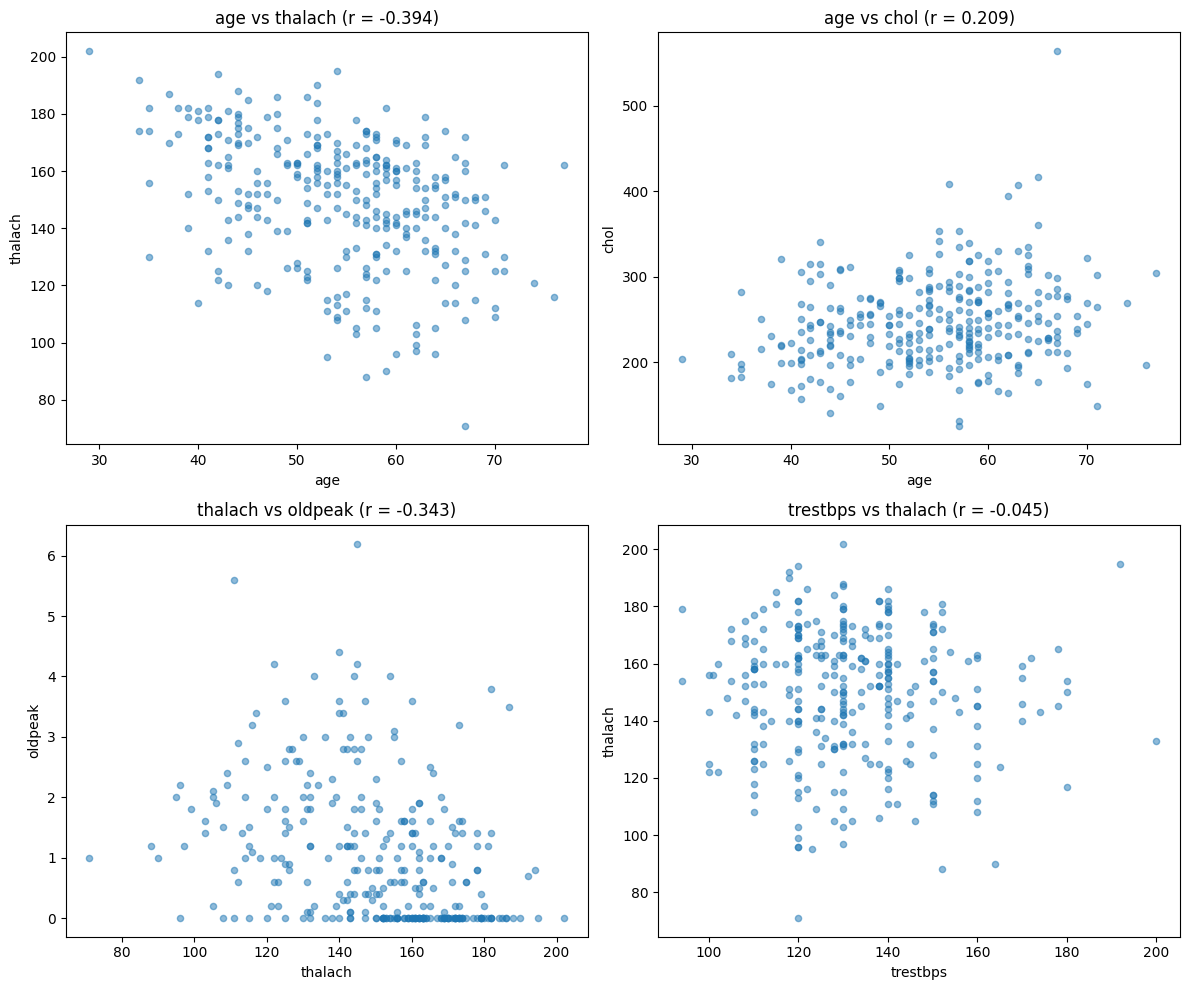

In [168]:
data_num_full = all_data[:, :len(numerical_cols)]

feature_labels = {
    'age':      'Age (years)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol':     'Serum Cholesterol (mg/dL)',
    'thalach':  'Max Heart Rate Achieved (bpm)',
    'oldpeak':  'ST Depression (mm)',
    'ca':       'Major Vessels Colored (0-3)',
}

pairs = [
    (0, 3, 'age', 'thalach'),
    (0, 2, 'age', 'chol'),
    (3, 4, 'thalach', 'oldpeak'),
    (1, 3, 'trestbps', 'thalach'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, (ci, cj, name_i, name_j) in enumerate(pairs):
    ax = axes[idx // 2, idx % 2]
    r = correlation_coefficient(data_num_full, ci, cj)
    ax.scatter(data_num_full[:, ci], data_num_full[:, cj],
               alpha=0.5, s=20, color='steelblue')
    ax.set_xlabel(feature_labels[name_i])
    ax.set_ylabel(feature_labels[name_j])
    short_i = feature_labels[name_i].split(' (')[0]
    short_j = feature_labels[name_j].split(' (')[0]
    ax.set_title(f'{short_i} vs {short_j}  (r = {r:.3f})')

plt.suptitle('Scatter Plots: Selected Numerical Feature Pairs', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/scatter_plots_3f.png', bbox_inches='tight')
plt.show()


**1. Age vs Max Heart Rate (r = -0.394):** Cardiovascular fitness naturally declines with age, so a negative relationship between age and peak exercise heart rate is expected on physiological grounds. The scatter plot supports this: older patients consistently achieve lower maximum heart rates, and the moderate negative correlation (r = -0.394) confirms the trend is robust enough to be analytically meaningful.

**2. Age vs Serum Cholesterol (r = 0.209):** Cholesterol accumulation tends to increase gradually over a lifetime, suggesting a positive relationship with age. The scatter plot shows a weak positive correlation (r = 0.209), which aligns with that expectation. The wide scatter reflects the many additional factors -- diet, genetics, medications -- that modulate cholesterol independently of age.

**3. Max Heart Rate vs ST Depression (r = -0.343):** Patients who achieve higher peak heart rates during exercise tend to show smaller ST-segment depressions, indicating better coronary perfusion. The moderate negative correlation (r = -0.343) supports this interpretation: impaired cardiovascular function simultaneously limits exercise heart rate capacity and myocardial blood supply.

**4. Resting Blood Pressure vs Max Heart Rate (r = -0.045):** Despite an initial expectation that these measures might be linked, the scatter plot shows essentially no linear relationship (r = -0.045). Resting blood pressure and exercise heart rate reflect different physiological mechanisms -- vascular resistance vs. cardiac output under load -- and are largely independent in this population.


## 3g) Range-Normalized Attributes with Largest Covariance

All numerical attributes are scaled to [0, 1] via range normalization. The pair with the largest estimated covariance in this normalized space is identified and plotted.


largest covariance: 0.021012
is between: age and ca


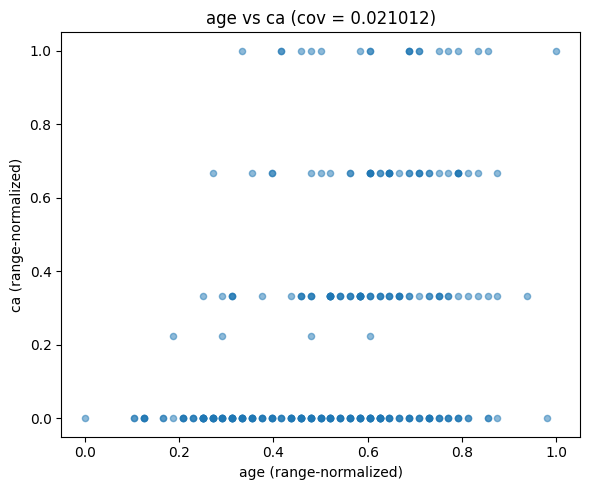

In [169]:
data_range_full = range_normalize(data_num_full)
cov_range = compute_covariance_matrix(data_range_full)

max_cov = -float('inf')
max_i, max_j = 0, 1
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        if cov_range[i, j] > max_cov:
            max_cov = cov_range[i, j]
            max_i, max_j = i, j

print(f'largest covariance: {max_cov:.6f}')
print(f'is between: {numerical_cols[max_i]} and {numerical_cols[max_j]}')

plt.figure(figsize=(6, 5))
plt.scatter(data_range_full[:, max_i], data_range_full[:, max_j], alpha=0.5, s=20)
plt.xlabel(f'{feature_labels[numerical_cols[max_i]]} (range-normalized)')
plt.ylabel(f'{feature_labels[numerical_cols[max_j]]} (range-normalized)')
short_i = feature_labels[numerical_cols[max_i]].split(' (')[0]
short_j = feature_labels[numerical_cols[max_j]].split(' (')[0]
plt.title(f'{short_i} vs {short_j}  (cov = {max_cov:.6f})')
plt.tight_layout()
plt.savefig('figures/scatter_3g.png', bbox_inches='tight')
plt.show()

### Finding

After range normalization, the pair with the largest estimated covariance is **age and ca** (number of major vessels colored by fluoroscopy), with a covariance of **0.0210**. This is consistent with clinical expectation: arterial calcification detectable by fluoroscopy is more prevalent in older patients, so age and the `ca` count tend to increase together. The scatter plot shows a clear positive trend, confirming that the covariance reflects a real relationship rather than noise.


## 3h) Z-Score Normalized Attributes with Largest Correlation

All numerical attributes are standardized to zero mean and unit variance. The pair with the largest Pearson correlation coefficient is identified and plotted.


Largest correlation: 0.359489
Between: age and ca


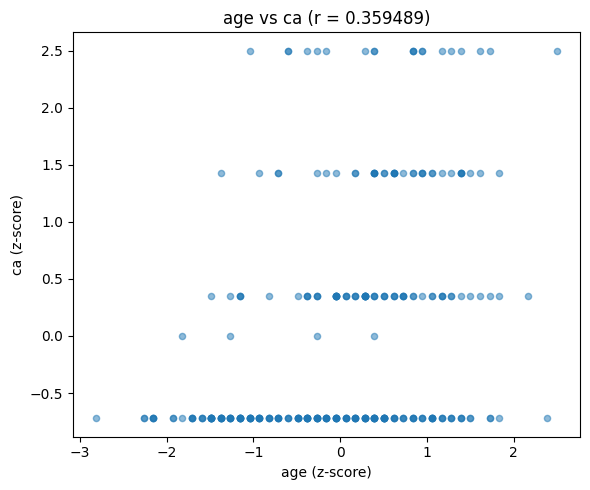

In [170]:
data_zscore_full = zscore_normalize(data_num_full)

max_corr = -float('inf')
max_i, max_j = 0, 1
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        r = correlation_coefficient(data_zscore_full, i, j)
        if r > max_corr:
            max_corr = r
            max_i, max_j = i, j

print(f'Largest correlation: {max_corr:.6f}')
print(f'Between: {numerical_cols[max_i]} and {numerical_cols[max_j]}')

plt.figure(figsize=(6, 5))
plt.scatter(data_zscore_full[:, max_i], data_zscore_full[:, max_j], alpha=0.5, s=20)
plt.xlabel(f'{feature_labels[numerical_cols[max_i]]} (z-score)')
plt.ylabel(f'{feature_labels[numerical_cols[max_j]]} (z-score)')
short_i = feature_labels[numerical_cols[max_i]].split(' (')[0]
short_j = feature_labels[numerical_cols[max_j]].split(' (')[0]
plt.title(f'{short_i} vs {short_j}  (r = {max_corr:.6f})')
plt.tight_layout()
plt.savefig('figures/scatter_3h.png', bbox_inches='tight')
plt.show()

### Finding

The z-score normalized pair with the largest Pearson correlation is **age and ca** (r = 0.3595). This result is consistent with the range-normalized covariance finding from 3g: both measures identify the same underlying relationship. The positive correlation reflects the well-documented clinical observation that arterial calcification increases with age. Note that the Pearson correlation is invariant to affine transformations (including z-score normalization), so this value matches what would be computed on the raw numerical data.


## 3i) Z-Score Normalized Attributes with Smallest Correlation

The pair with the smallest (most negative) Pearson correlation coefficient is identified from the z-score normalized data and plotted.


smallest corr: -0.393806
is between: age and thalach


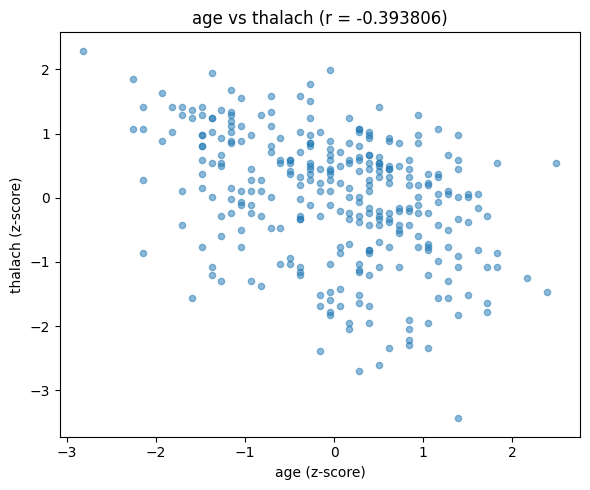

In [171]:
data_zscore_full = zscore_normalize(data_num_full)

min_corr = float('inf')
min_i, min_j = 0, 1
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        r = correlation_coefficient(data_zscore_full, i, j)
        if r < min_corr:
            min_corr = r
            min_i, min_j = i, j

print(f'smallest corr: {min_corr:.6f}')
print(f'is between: {numerical_cols[min_i]} and {numerical_cols[min_j]}')

plt.figure(figsize=(6, 5))
plt.scatter(data_zscore_full[:, min_i], data_zscore_full[:, min_j], alpha=0.5, s=20)
plt.xlabel(f'{feature_labels[numerical_cols[min_i]]} (z-score)')
plt.ylabel(f'{feature_labels[numerical_cols[min_j]]} (z-score)')
short_i = feature_labels[numerical_cols[min_i]].split(' (')[0]
short_j = feature_labels[numerical_cols[min_j]].split(' (')[0]
plt.title(f'{short_i} vs {short_j}  (r = {min_corr:.6f})')
plt.tight_layout()
plt.savefig('figures/scatter_3i.png', bbox_inches='tight')
plt.show()

### Finding

The pair with the smallest correlation coefficient is **age and thalach** (r = -0.3938). This negative relationship reflects the physiological reality that maximum exercise heart rate declines with age -- a well-established phenomenon in cardiology often approximated by the formula 220 minus age. The scatter plot shows a consistent downward trend, and the moderate magnitude of the correlation indicates that age accounts for a meaningful but not overwhelming proportion of the variance in peak heart rate.


## 3j) Feature Pairs with Correlation >= 0.5

A threshold of r = 0.5 is applied to identify pairs of numerical attributes with a strong positive linear relationship.


In [172]:
count = 0
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        r = correlation_coefficient(data_num_full, i, j)
        if r >= 0.5:
            print(f'  {numerical_cols[i]} & {numerical_cols[j]}: r = {r:.6f}')
            count += 1

print(count)

0


### Finding

No pairs of numerical features have a Pearson correlation coefficient of 0.5 or greater. The highest observed pairwise correlation is the age-ca pair at approximately r = 0.36, indicating that the six numerical features are not strongly collinear. This is a favorable property for downstream predictive modeling, as it suggests each feature contributes relatively independent information and that multicollinearity is unlikely to be a concern.


## 3k) Feature Pairs with Negative Covariance

Pairs of numerical features with negative estimated covariance are identified. A negative covariance indicates that as one feature increases, the other tends to decrease.


In [173]:
count = 0
for i in range(len(numerical_cols)):
    for j in range(i +1, len(numerical_cols)):
        cov = sample_covariance(data_num_full, i, j)
        if cov < 0:
            print(f'.  {numerical_cols[i]} & {numerical_cols[j]}: cov = {cov:.4f}')
            count += 1

print(f'\npairs with negative cov: {count}')

.  age & thalach: cov = -81.4231
.  trestbps & thalach: cov = -18.2580
.  chol & thalach: cov = -4.0647
.  thalach & oldpeak: cov = -9.1122
.  thalach & ca: cov = -5.6110

pairs with negative cov: 5


### Finding

Five pairs of numerical features have negative estimated covariance, and all five involve `thalach` (maximum heart rate achieved). This is physiologically coherent: a higher peak heart rate is generally associated with better cardiovascular health, so it tends to move in the opposite direction from risk indicators such as age, resting blood pressure, cholesterol, ST depression, and the number of calcified vessels. The consistent negative sign across all five pairs reinforces `thalach` as one of the most informative features in the dataset.


## 3l) Total Variance of the Data

The total variance is the sum of the diagonal entries of the covariance matrix -- that is, the sum of individual feature variances across all columns of the full expanded feature matrix.


In [174]:
cov_all = compute_covariance_matrix(all_data)

total_variance = 0.0
for i in range(len(all_cols)):
    total_variance += cov_all[i, i]

print(f'total var: {total_variance:.4f}')

total var: 3601.8383


## 3m) Variance Ratio of the Top 5 Features

The five features with the highest individual variance are identified, and their combined variance is expressed as a proportion of the total variance across all features. This ratio indicates how much of the overall data spread is captured by just the most variable columns.

*Ratio = (sum of top-5 feature variances) / (total variance)*


In [175]:
var = []
for i in range(len(all_cols)):
    var.append((cov_all[i, i], all_cols[i]))

var.sort(reverse=True)

print('top 5 features by variance:')
top5 = 0.0
for var, name in var[:5]:
    print(f'  {name}: {var:.4f}')
    top5 += var

ratio = top5 / total_variance
print(f'\nTop 5 variance: {top5:.4f}')
print(f'Total variance: {total_variance:.4f}')
print(f'Ratio: {ratio:.6f} ({ratio * 100:.2f}%)')

top 5 features by variance:
  chol: 2680.8492
  thalach: 523.2658
  trestbps: 309.7511
  age: 81.6974
  oldpeak: 1.3481

Top 5 variance: 3596.9116
Total variance: 3601.8383
Ratio: 0.998632 (99.86%)


### Finding

The five features with the highest estimated variance account for **99.86%** of the total variance in the dataset (ratio ~= 0.9986). This result is largely driven by measurement scale: attributes such as `chol` (cholesterol in mg/dL) and `trestbps` (blood pressure in mm Hg) have much larger absolute variance than the binary and one-hot encoded categorical columns, which are bounded between 0 and 1. This illustrates why normalization is critical before any distance-based or variance-sensitive analysis -- raw variance is dominated by measurement units, not necessarily by clinical relevance.
